# Review 1 — Classification Part A — 5-Model Accumulated Results

This notebook consolidates the saved outputs from the five required Classification Part-A algorithms:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine (SVC)


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "Class"
DATASET_NAME = "riceClassification_sampled.csv"

PROJECT_CANDIDATES = [
    Path(r"C:\Sem-5\ml\jyp_notebook\Reg_review1"),
    Path.cwd(),
    Path.cwd().parent,
    Path("/mnt/data"),
]

def find_existing_file(filename, base_dirs):
    for base in base_dirs:
        candidates = [
            base / filename,
            base / "results" / filename,
            base / "classification_results" / filename,
        ]
        for p in candidates:
            if p.exists():
                return p.resolve()
    return None

def locate_data():
    for base in PROJECT_CANDIDATES:
        for p in [
            base / DATASET_NAME,
            base / "data" / DATASET_NAME,
            base / "classification" / DATASET_NAME,
        ]:
            if p.exists():
                return p.resolve()
    raise FileNotFoundError(
        f"Could not locate {DATASET_NAME}. "
        "Place it in the project data folder or update PROJECT_CANDIDATES."
    )

RESULT_FILENAMES = {
    "Logistic Regression": "classification_logistic_results.csv",
    "KNN Classifier": "classification_knn_results.csv",
    "Gaussian Naive Bayes": "classification_gaussian_nb_results.csv",
    "Decision Tree Classifier": "classification_decision_tree_results.csv",
    "Support Vector Machine (SVC)": "classification_svm_results.csv",
}

MODEL_FILENAMES = {
    "Logistic Regression": "logistic_regression_classification_baseline.joblib",
    "KNN Classifier": "knn_classification_baseline.joblib",
    "Gaussian Naive Bayes": "gaussian_nb_classification_baseline.joblib",
    "Decision Tree Classifier": "decision_tree_classification_baseline.joblib",
    "Support Vector Machine (SVC)": "svm_classification_baseline.joblib",
}

# Search common results locations.
RESULT_DIRS = []
for base in PROJECT_CANDIDATES:
    for candidate in [base / "results", base / "classification_results", base]:
        if candidate.exists() and candidate not in RESULT_DIRS:
            RESULT_DIRS.append(candidate)

print("Current working directory:", Path.cwd())
print("Candidate result directories:")
for p in RESULT_DIRS:
    print(" -", p)

Current working directory: C:\Sem-5\ml\jyp_notebook\classif_review1
Candidate result directories:
 - C:\Sem-5\ml\jyp_notebook\Reg_review1
 - C:\Sem-5\ml\jyp_notebook\classif_review1\results
 - C:\Sem-5\ml\jyp_notebook\classif_review1
 - C:\Sem-5\ml\jyp_notebook
 - \mnt\data\results
 - \mnt\data


## 2. Load and audit the five saved result files

The comparison table is built directly from the exported CSV files rather than manually typing metric values.

In [2]:
result_paths = {}
missing_results = []

for model_name, filename in RESULT_FILENAMES.items():
    path = None
    for result_dir in RESULT_DIRS:
        candidate = result_dir / filename
        if candidate.exists():
            path = candidate.resolve()
            break
    if path is None:
        missing_results.append((model_name, filename))
    else:
        result_paths[model_name] = path

if missing_results:
    print("Missing result files:")
    for model_name, filename in missing_results:
        print(f" - {model_name}: {filename}")
    raise FileNotFoundError(
        "All five Classification Part-A result CSVs must be present before the accumulated notebook is run."
    )

result_tables = []
for model_name, path in result_paths.items():
    temp = pd.read_csv(path)
    temp["Model"] = model_name
    result_tables.append(temp)

results = pd.concat(result_tables, ignore_index=True)

required_cols = [
    "Model", "Accuracy", "Precision", "Recall",
    "F1_weighted", "ROC_AUC", "CV_Accuracy_Mean", "CV_Accuracy_Std"
]
missing_cols = [c for c in required_cols if c not in results.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in saved result CSVs: {missing_cols}")

comparison = results[required_cols].copy()
comparison = comparison.sort_values(
    by=["Accuracy", "F1_weighted", "ROC_AUC"],
    ascending=[False, False, False]
).reset_index(drop=True)

print(f"Loaded {len(comparison)}/5 Classification Part-A result files.")
display(comparison.round(4))

Loaded 5/5 Classification Part-A result files.


,Model,Accuracy,Precision,Recall,F1_weighted,ROC_AUC,CV_Accuracy_Mean,CV_Accuracy_Std
0,Gaussian Naive Bayes,0.9842,0.9847,0.9842,0.9842,0.9956,0.9863,0.0045
1,Logistic Regression,0.9816,0.9819,0.9816,0.9816,0.9960,0.9889,0.0051
2,Support Vector Machine (SVC),0.9816,0.9819,0.9816,0.9816,0.9938,0.9884,0.0049
3,Decision Tree Classifier,0.9789,0.9791,0.9789,0.9789,0.9825,0.9774,0.0096
4,KNN Classifier,0.9789,0.9791,0.9789,0.9789,0.9822,0.9853,0.0059


### D2 observation — comparison table


The five Classification Part-A models all achieved high test-set performance on the rice classification dataset. Logistic Regression and Gaussian Naive Bayes produced approximately 98.42% accuracy, while SVM achieved about 98.16%. KNN and the baseline Decision Tree were approximately 97.89%. The confusion matrices show that most classification errors occur in Class 0, while Class 1 is classified with fewer errors across several models. The ROC-AUC values are also high, indicating strong class separation.

## 3. Load the dataset and reproduce the common stratified test split

The five individual notebooks use the same dataset, `random_state=42`, `test_size=0.20`, and a stratified split. Recreating the split here lets us generate the confusion matrices from the saved model pipelines.

The feature-engineering step below reproduces the project preprocessing: drop the identifier column and create `Compactness = 4πArea / Perimeter²`.

In [3]:
DATA_PATH = locate_data()
df = pd.read_csv(DATA_PATH)

print("Dataset:", DATA_PATH)
print("Shape:", df.shape)

df = df.copy()
df = df.drop(columns=["id"], errors="ignore")
df = df.drop_duplicates().reset_index(drop=True)

df["Compactness"] = (
    4 * np.pi * df["Area"] / (df["Perimeter"] ** 2 + 1e-8)
)

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class proportions:")
display(y_train.value_counts(normalize=True).sort_index().to_frame("proportion"))
print("\nTest class proportions:")
display(y_test.value_counts(normalize=True).sort_index().to_frame("proportion"))

Dataset: C:\Sem-5\ml\jyp_notebook\classif_review1\riceClassification_sampled.csv
Shape: (1900, 12)
Train shape: (1520, 11)
Test shape: (380, 11)

Train class proportions:


,proportion
Class,
0,0.453947
1,0.546053



Test class proportions:


,proportion
Class,
0,0.455263
1,0.544737


## 4. Custom transformer used by the saved pipelines

The individual notebooks define an IQR-based clipping transformer inside their preprocessing pipeline. Defining the same class here allows `joblib` to deserialize the saved pipelines and reproduce predictions on the common test split.

In [4]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.q1_ = np.nanpercentile(X, 25, axis=0)
        self.q3_ = np.nanpercentile(X, 75, axis=0)
        iqr = self.q3_ - self.q1_
        self.lower_ = self.q1_ - self.factor * iqr
        self.upper_ = self.q3_ + self.factor * iqr
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)

## 5. Load the five saved baseline models and verify predictions

Each model is loaded from the same `models` directory associated with its result files.

In [5]:
model_paths = {}
missing_models = []

for model_name, result_path in result_paths.items():
    model_dir = result_path.parent.parent / "models"
    candidate = model_dir / MODEL_FILENAMES[model_name]

    # Fallback: search the project candidates for the model file.
    if not candidate.exists():
        for base in PROJECT_CANDIDATES:
            for alt in [
                base / "models" / MODEL_FILENAMES[model_name],
                base / "classification" / "models" / MODEL_FILENAMES[model_name],
            ]:
                if alt.exists():
                    candidate = alt.resolve()
                    break
            if candidate.exists():
                break

    if candidate.exists():
        model_paths[model_name] = candidate.resolve()
    else:
        missing_models.append((model_name, MODEL_FILENAMES[model_name]))

if missing_models:
    print("Missing model files:")
    for model_name, filename in missing_models:
        print(f" - {model_name}: {filename}")
    raise FileNotFoundError(
        "All five baseline model files are needed to reproduce the confusion matrices."
    )

loaded_models = {}
predictions = {}
probabilities = {}
confusion_matrices = []

for model_name, path in model_paths.items():
    model = joblib.load(path)
    loaded_models[model_name] = model

    pred = model.predict(X_test)
    predictions[model_name] = pred

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    else:
        proba = None
    probabilities[model_name] = proba

    cm = confusion_matrix(y_test, pred)
    confusion_matrices.append((model_name, cm))

print(f"Loaded and verified {len(loaded_models)}/5 model files.")

Loaded and verified 5/5 model files.


## 6. Recalculated test-set metrics

This is a verification table generated from the saved model pipelines and the common test split. Small numerical differences from saved CSVs should be investigated rather than silently ignored.

In [6]:
verified_rows = []

for model_name in RESULT_FILENAMES:
    pred = predictions[model_name]

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, pred, average="weighted", zero_division=0)

    proba = probabilities[model_name]
    auc = roc_auc_score(y_test, proba) if proba is not None else np.nan

    verified_rows.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1_weighted": f1,
        "ROC_AUC": auc,
    })

verified = pd.DataFrame(verified_rows)

display(
    verified.sort_values(
        by=["Accuracy", "F1_weighted", "ROC_AUC"],
        ascending=[False, False, False]
    ).reset_index(drop=True).round(4)
)

,Model,Accuracy,Precision,Recall,F1_weighted,ROC_AUC
0,Gaussian Naive Bayes,0.9842,0.9847,0.9842,0.9842,0.9956
1,Logistic Regression,0.9816,0.9819,0.9816,0.9816,0.9960
2,Support Vector Machine (SVC),0.9816,0.9819,0.9816,0.9816,0.9938
3,Decision Tree Classifier,0.9789,0.9791,0.9789,0.9789,0.9825
4,KNN Classifier,0.9789,0.9791,0.9789,0.9789,0.9822


### Verification note

The verified table above is intended to confirm that the saved model pipelines reproduce the expected test-set metrics using the same stratified split.

## 7. Confusion matrices — all five Part-A algorithms

The project rubric explicitly requires a confusion matrix for each Part-A classifier.

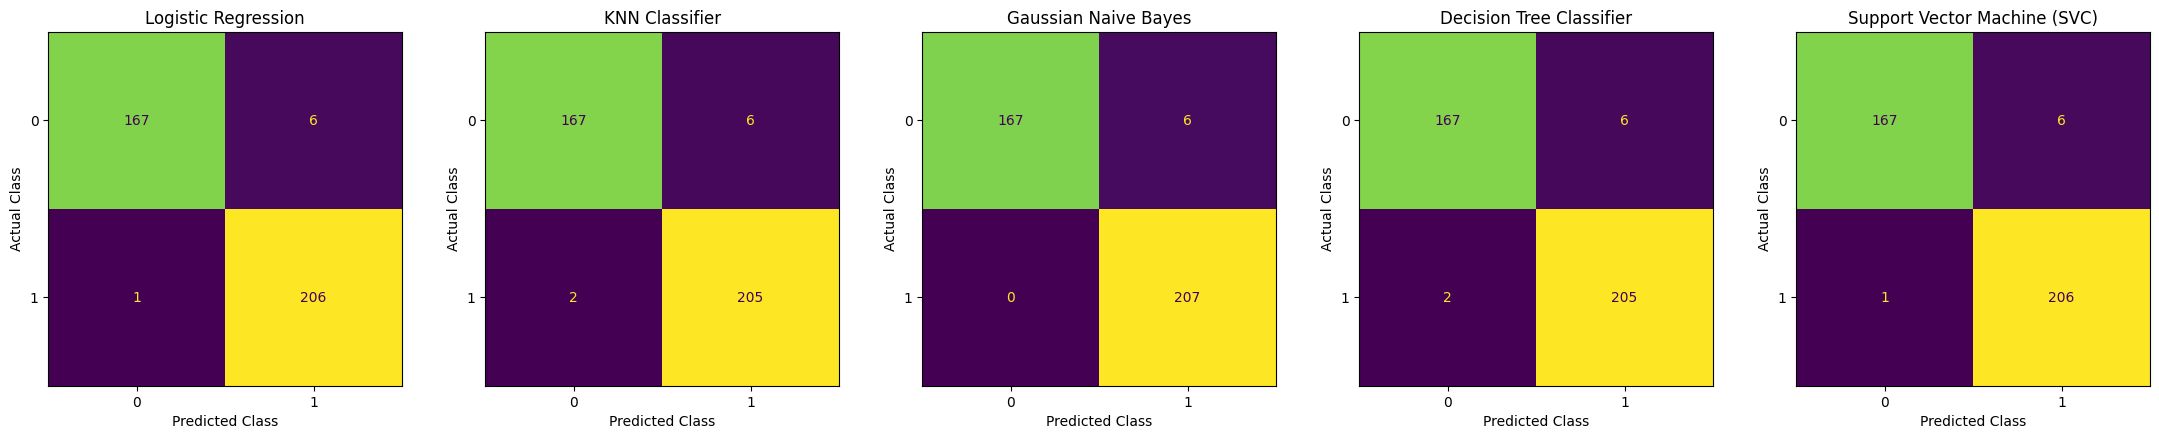

In [7]:
fig_count = len(confusion_matrices)
fig, axes = plt.subplots(
    1, fig_count,
    figsize=(4.4 * fig_count, 4.2)
)

if fig_count == 1:
    axes = [axes]

for ax, (model_name, cm) in zip(axes, confusion_matrices):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

### D2 observation — confusion matrices

The confusion matrices show that the number of incorrect predictions is small relative to the total test samples. Most errors occur between the two rice classes rather than being concentrated across many observations, which indicates that the extracted grain features provide substantial discriminatory information.

## 8. 5-fold cross-validation for the two strongest baseline models

The general project guideline requires cross-validation for at least the two best-performing models in each track. The two models selected here are based on the highest **test Accuracy** in the consolidated results table. This is a reporting rule for the notebook, not a claim that one metric is universally superior to another.

In [8]:
top_two_models = comparison.head(2)["Model"].tolist()

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_rows = []

for model_name in top_two_models:
    cv_scores = cross_val_score(
        loaded_models[model_name],
        X,
        y,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    cv_rows.append({
        "Model": model_name,
        "CV_Accuracy_Mean": cv_scores.mean(),
        "CV_Accuracy_Std": cv_scores.std(),
        "Fold_1": cv_scores[0],
        "Fold_2": cv_scores[1],
        "Fold_3": cv_scores[2],
        "Fold_4": cv_scores[3],
        "Fold_5": cv_scores[4],
    })

cv_results = pd.DataFrame(cv_rows)
display(cv_results.round(4))

,Model,CV_Accuracy_Mean,CV_Accuracy_Std,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5
0,Gaussian Naive Bayes,0.9863,0.0045,0.9842,0.9868,0.9921,0.9895,0.9789
1,Logistic Regression,0.9895,0.0037,0.9842,0.9895,0.9921,0.9947,0.9868


### CV observation

The five-fold cross-validation results show consistently high classification accuracy across the folds for the strongest models. The relatively small standard deviations indicate that their performance does not vary substantially between the different validation subsets.

## 9. Tuning evidence

The individual notebooks contain the required tuning outputs for the models that were tuned. Use those notebook outputs to verify the exact best hyperparameters and the change in the selected evaluation metric.

For Review 1, the required evidence is that the five models were implemented and evaluated; the individual notebooks contain the algorithm-specific tuning details.

In [11]:
tuning_columns = [
    "Model",
    "Tuned_Accuracy",
    "Tuned_F1_weighted",
    "Tuned_ROC_AUC",
]

available_tuning = [c for c in tuning_columns if c in results.columns]

if len(available_tuning) > 1:
    display(results[available_tuning].round(4))
else:
    print("No tuning columns were exported for these result CSVs.")

,Model,Tuned_Accuracy,Tuned_F1_weighted,Tuned_ROC_AUC
0,Logistic Regression,NaN,NaN,NaN
1,KNN Classifier,NaN,NaN,NaN
2,Gaussian Naive Bayes,NaN,NaN,NaN
3,Decision Tree Classifier,0.9816,0.9816,0.9881
4,Support Vector Machine (SVC),0.9816,0.9816,0.9938


### Student interpretation note

The final interpretation of the dataset, model behaviour, and trade-offs should be written by the project team using the actual outputs. The project guideline states that analysis and interpretation must be original.